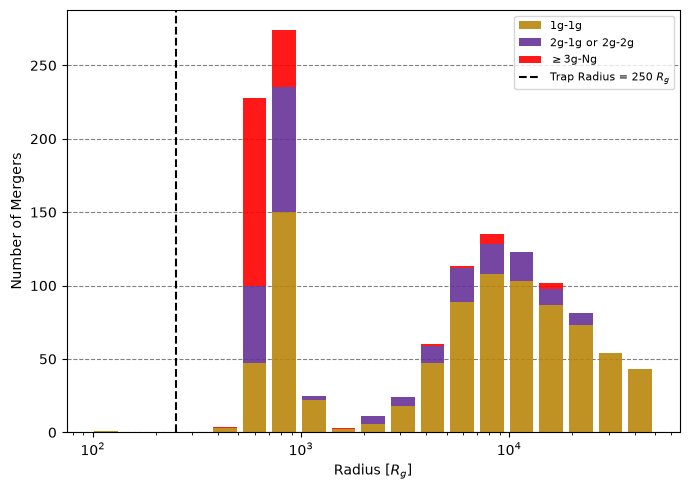

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from mcfacts.vis import styles

data = pd.read_csv("/Users/vprit/McFACTS/runs/population_blackholes_merged.txt", sep=r"\s+")

#radius of merger
orb_a = data["orb_a::numpy.float64"].to_numpy()

#time of merger 
time_merged = data["time_merged::numpy.float64"].to_numpy()

# Generation of the merger remnant
gen_final = data["gen_final::numpy.int64"].to_numpy()

#only for radius above 0 
valid = np.isfinite(orb_a) & (orb_a > 0)

orb_a = orb_a[valid]
time_merged = time_merged[valid]
gen_final = gen_final[valid]

# 1g-1g mergers
g1_radius = orb_a[gen_final == 2]

# 2g-1g or 2g-2g mergers
g2_radius = orb_a[gen_final == 3]

# >=3g mergers
gX_radius = orb_a[gen_final >= 4]

#bins

bins = np.geomspace(orb_a.min(), orb_a.max(), 20)

#plotting
fig, ax = plt.subplots(figsize=(7, 5))

ax.hist([g1_radius, g2_radius, gX_radius], bins=bins, color=[styles.color_gen1, styles.color_gen2, styles.color_genX],  alpha=0.9, rwidth=0.8, label=[ "1g-1g", "2g-1g or 2g-2g", r"$\geq$3g-Ng"],stacked=True)

ax.set_xlabel(r"Radius [$R_g$]")
ax.set_ylabel("Number of Mergers")

ax.set_xscale("log")

ax.set_axisbelow(True)
ax.grid(True, axis="y", color="gray", linestyle="--")

# trap radius.
trap_radius = 250

ax.axvline(trap_radius, color="k", linestyle="--", label=f"Trap Radius = {trap_radius} $R_g$")

ax.legend(fontsize=8)

plt.tight_layout()


plt.savefig("/Users/vprit/Desktop/Work/Coding/mcfacts/UCC/mergers_vs_radius.png", dpi=300)

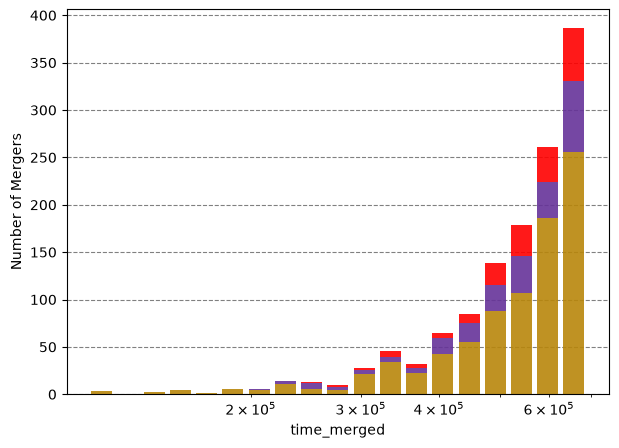

In [3]:
# 1g-1g mergers
g1_time = time_merged[gen_final == 2]

# 2g-1g or 2g-2g mergers
g2_time = time_merged[gen_final == 3]

# >=3g mergers
gX_time = time_merged[gen_final >= 4]

#bins

bins = np.geomspace(time_merged.min(), time_merged.max(), 20)

#plotting
fig, ax = plt.subplots(figsize=(7, 5))

ax.hist([g1_time, g2_time, gX_time], bins=bins, color=[styles.color_gen1, styles.color_gen2, styles.color_genX],  alpha=0.9, rwidth=0.8, label=[ "1g-1g", "2g-1g or 2g-2g", r"$\geq$3g-Ng"],stacked=True)

ax.set_xlabel("time_merged")
ax.set_ylabel("Number of Mergers")

ax.set_xscale("log")

ax.set_axisbelow(True)
ax.grid(True, axis="y", color="gray", linestyle="--")

plt.savefig("/Users/vprit/Desktop/Work/Coding/mcfacts/UCC/mergers_vs_time.png", dpi=300)